In [91]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    "../data/kerala_crop_project_final_15000_recent.csv"
)


# ============================================================
# HANDLE MISSING VALUES
# ============================================================

for col in df.select_dtypes(include=["number"]).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=["object", "str"]).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])


# ============================================================
# FEATURES
# ============================================================

features = [
    
    "Soil_Type",
    "Soil_pH",
    "Nitrogen_N_kg_ha",
    "Phosphorus_P_kg_ha",
    "Potassium_K_kg_ha",
    "Rainfall_mm",
    "Temperature_C",
    "Humidity_percent",
    "Irrigation_Level",
    "Season"
]

X = df[features].copy()
y = df["Crop"].astype(str)


# ============================================================
# ENCODE CATEGORICAL FEATURES
# ============================================================

for col in [
    "Soil_Type",
    "Irrigation_Level",
    "Season"
]:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )


# ============================================================
# ENCODE TARGET
# ============================================================

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# ============================================================
# SCALE FEATURES
# Helps Logistic Regression, KNN and SVM
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# MODELS
# ============================================================

models = {


    "Decision Tree":
        (DecisionTreeClassifier(random_state=42),
         X_train,
         X_test),

    "Random Forest":
        (RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),
         X_train,
         X_test),

    "KNN":
        (KNeighborsClassifier(n_neighbors=5),
         X_train_scaled,
         X_test_scaled),

    "SVM":
    (
        SVC(
            C=0.5,
            kernel="rbf",
            gamma=0.01
        ),
        X_train_scaled,
        X_test_scaled
    ),


}


# ============================================================
# TRAIN AND SHOW ACCURACY ONLY
# ============================================================

print("=" * 50)
print("CROP RECOMMENDATION - ACCURACY")
print("=" * 50)

results = []

for name, (model, train_data, test_data) in models.items():

    model.fit(
        train_data,
        y_train
    )

    prediction = model.predict(
        test_data
    )

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    results.append(
        [name, accuracy]
    )

    print(
        f"{name:<25} : {accuracy:.2%}"
    )


# ============================================================
# BEST MODEL
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=["Algorithm", "Accuracy"]
)

best = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("\n" + "=" * 50)
print("BEST ALGORITHM")
print("=" * 50)

print("Algorithm :", best["Algorithm"])
print("Accuracy  :", f"{best['Accuracy']:.2%}")

CROP RECOMMENDATION - ACCURACY
Decision Tree             : 75.93%
Random Forest             : 83.62%
KNN                       : 79.18%
SVM                       : 83.56%

BEST ALGORITHM
Algorithm : Random Forest
Accuracy  : 83.62%


In [90]:
import pandas as pd
import warnings
import os
import joblib

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    "../data/kerala_crop_project_final_15000_recent.csv"
)

print("Dataset loaded:", df.shape)


# ============================================================
# HANDLE MISSING VALUES
# ============================================================

for col in df.select_dtypes(include=["number"]).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=["object", "str"]).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])


# ============================================================
# FEATURES
# ============================================================

features = [
    "Soil_Type",
    "Soil_pH",
    "Nitrogen_N_kg_ha",
    "Phosphorus_P_kg_ha",
    "Potassium_K_kg_ha",
    "Rainfall_mm",
    "Temperature_C",
    "Humidity_percent",
    "Irrigation_Level",
    "Season"
]

X = df[features].copy()
y = df["Crop"].astype(str)


# ============================================================
# ENCODE FEATURES
# ============================================================

feature_encoders = {}

for col in [
    "Soil_Type",
    "Irrigation_Level",
    "Season"
]:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )

    feature_encoders[col] = encoder


# ============================================================
# ENCODE TARGET
# ============================================================

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# ============================================================
# MODELS
# ============================================================

models = {

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC()
}


# ============================================================
# TRAIN AND SHOW ACCURACY
# ============================================================

print("\n")
print("=" * 60)
print("       CROP RECOMMENDATION - ACCURACY")
print("=" * 60)

results = {}

trained_models = {}


for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    prediction = model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    results[name] = accuracy
    trained_models[name] = model

    print(
        f"{name:<25} : {accuracy:.2%}"
    )


# ============================================================
# RANDOM FOREST
# ============================================================

random_forest_model = trained_models[
    "Random Forest"
]

rf_accuracy = results[
    "Random Forest"
]


print("\n")
print("=" * 60)
print("             RANDOM FOREST")
print("=" * 60)

print(
    "Accuracy :",
    f"{rf_accuracy:.2%}"
)


# ============================================================
# SAVE EVERYTHING IN ONE FILE
# ============================================================

model_package = {

    "model": random_forest_model,

    "feature_encoders": feature_encoders,

    "target_encoder": target_encoder,

    "features": features
}


# ============================================================
# CREATE MODELS FOLDER
# ============================================================

save_folder = "../models"

os.makedirs(
    save_folder,
    exist_ok=True
)


# ============================================================
# SAVE MODEL
# ============================================================

model_path = os.path.join(
    save_folder,
    "crop_recommendation_model.pkl"
)

joblib.dump(
    model_package,
    model_path
)


# ============================================================
# FINAL
# ============================================================

print("\n")
print("=" * 60)
print("             MODEL SAVED")
print("=" * 60)

print(
    "Saved at:",
    model_path
)

Dataset loaded: (15000, 21)


       CROP RECOMMENDATION - ACCURACY
Decision Tree             : 75.93%
Random Forest             : 83.62%
KNN                       : 54.80%
SVM                       : 20.42%


             RANDOM FOREST
Accuracy : 83.62%


             MODEL SAVED
Saved at: ../models\crop_recommendation_model.pkl


In [ ]:
# import pandas as pd
# import numpy as np
# import warnings

# warnings.filterwarnings("ignore")

# from sklearn.model_selection import train_test_split
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.pipeline import Pipeline

# from sklearn.metrics import (
#     r2_score,
#     mean_absolute_error,
#     mean_squared_error
# )

# from sklearn.linear_model import Ridge
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import (
#     RandomForestRegressor,
#     GradientBoostingRegressor
# )


# # ============================================================
# # LOAD DATASET
# # ============================================================

# df = pd.read_csv(
#     "../data/kerala_crop_project_final_15000_recent.csv"
# )

# print("Dataset loaded:", df.shape)


# # ============================================================
# # TARGET
# # ============================================================

# df["Yield_kg_ha"] = pd.to_numeric(
#     df["Yield_kg_ha"],
#     errors="coerce"
# )

# df = df.dropna(
#     subset=["Yield_kg_ha"]
# )


# # ============================================================
# # FEATURES
# # ============================================================

# features = [
#     "Crop",
#     "Soil_Type",
#     "Soil_pH",
#     "Nitrogen_N_kg_ha",
#     "Phosphorus_P_kg_ha",
#     "Potassium_K_kg_ha",
#     "Rainfall_mm",
#     "Temperature_C",
#     "Humidity_percent",
#     "Irrigation_Level",
#     "Season"
# ]

# X = df[features].copy()
# y = df["Yield_kg_ha"].copy()


# # ============================================================
# # FEATURE TYPES
# # ============================================================

# categorical_features = [
#     "Crop",
#     "Soil_Type",
#     "Irrigation_Level",
#     "Season"
# ]

# numeric_features = [
#     "Soil_pH",
#     "Nitrogen_N_kg_ha",
#     "Phosphorus_P_kg_ha",
#     "Potassium_K_kg_ha",
#     "Rainfall_mm",
#     "Temperature_C",
#     "Humidity_percent"
# ]


# # ============================================================
# # MISSING VALUES
# # ============================================================

# for col in numeric_features:
#     X[col] = X[col].fillna(
#         X[col].median()
#     )

# for col in categorical_features:
#     X[col] = X[col].fillna(
#         X[col].mode()[0]
#     )


# # ============================================================
# # TRAIN TEST SPLIT
# # ============================================================

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.30,
#     random_state=42
# )


# # ============================================================
# # ENCODING
# # ============================================================

# preprocessor = ColumnTransformer(
#     transformers=[
#         (
#             "categorical",
#             OneHotEncoder(
#                 handle_unknown="ignore"
#             ),
#             categorical_features
#         )
#     ],
#     remainder="passthrough"
# )


# # ============================================================
# # MODELS
# # ============================================================

# models = {

#     "Ridge Regression":
#         Ridge(
#             alpha=1000
#         ),

#     "Decision Tree":
#         DecisionTreeRegressor(
#             max_depth=2,
#             min_samples_split=350,
#             min_samples_leaf=175,
#             max_features=0.4,
#             random_state=42
#         ),

#     "Random Forest":
#         RandomForestRegressor(
#             n_estimators=30,
#             max_depth=3,
#             min_samples_split=150,
#             min_samples_leaf=75,
#             max_features=0.3,
#             random_state=42,
#             n_jobs=-1
#         ),

#     "Gradient Boosting":
#         GradientBoostingRegressor(
#             n_estimators=50,
#             max_depth=1,
#             learning_rate=0.03,
#             min_samples_split=200,
#             min_samples_leaf=100,
#             random_state=42
#         )
# }


# # ============================================================
# # TRAIN + EVALUATION
# # ============================================================

# print("\n")
# print("=" * 75)
# print("             CROP YIELD PREDICTION")
# print("=" * 75)

# results = []


# for name, model in models.items():

#     pipeline = Pipeline(
#         steps=[
#             ("preprocessor", preprocessor),
#             ("model", model)
#         ]
#     )

#     # --------------------------------------------------------
#     # TRAIN
#     # --------------------------------------------------------

#     pipeline.fit(
#         X_train,
#         y_train
#     )

#     # --------------------------------------------------------
#     # PREDICTION
#     # --------------------------------------------------------

#     prediction = pipeline.predict(
#         X_test
#     )

#     # --------------------------------------------------------
#     # METRICS
#     # --------------------------------------------------------

#     r2 = r2_score(
#         y_test,
#         prediction
#     )

#     mae = mean_absolute_error(
#         y_test,
#         prediction
#     )

#     rmse = np.sqrt(
#         mean_squared_error(
#             y_test,
#             prediction
#         )
#     )

#     # --------------------------------------------------------
#     # STORE RESULTS
#     # --------------------------------------------------------

#     results.append(
#         [
#             name,
#             r2,
#             mae,
#             rmse
#         ]
#     )

#     # --------------------------------------------------------
#     # PRINT
#     # --------------------------------------------------------

#     print(
#         f"{name:<25} "
#         f"R²: {r2:.4f}   "
#         f"MAE: {mae:.2f}   "
#         f"RMSE: {rmse:.2f}"
#     )


# # ============================================================
# # RESULT DATAFRAME
# # ============================================================

# results_df = pd.DataFrame(
#     results,
#     columns=[
#         "Algorithm",
#         "R2 Score",
#         "MAE",
#         "RMSE"
#     ]
# )


# # ============================================================
# # DISPLAY RESULT
# # ============================================================

# print("\n")
# print("=" * 75)
# print("                         RESULT")
# print("=" * 75)

# print(
#     results_df.to_string(
#         index=False
#     )
# )


# # ============================================================
# # BEST ALGORITHM BASED ON R²
# # ============================================================

# best = results_df.loc[
#     results_df["R2 Score"].idxmax()
# ]


# print("\n")
# print("=" * 75)
# print("                    BEST ALGORITHM")
# print("=" * 75)

# print(
#     "Algorithm :",
#     best["Algorithm"]
# )

# print(
#     "R² Score  :",
#     f"{best['R2 Score']:.4f}"
# )

# print(
#     "MAE       :",
#     f"{best['MAE']:.2f}"
# )

# print(
#     "RMSE      :",
#     f"{best['RMSE']:.2f}"
# )

Dataset loaded: (15000, 21)


             CROP YIELD PREDICTION
Ridge Regression          R²: 0.6409   MAE: 4027.85   RMSE: 6588.51
Decision Tree             R²: 0.6273   MAE: 3484.51   RMSE: 6711.37
Random Forest             R²: 0.8831   MAE: 2702.08   RMSE: 3758.44
Gradient Boosting         R²: 0.7141   MAE: 4391.20   RMSE: 5878.74


                         RESULT
        Algorithm  R2 Score         MAE        RMSE
 Ridge Regression  0.640866 4027.854582 6588.506286
    Decision Tree  0.627347 3484.506645 6711.367588
    Random Forest  0.883131 2702.076658 3758.441740
Gradient Boosting  0.714076 4391.198621 5878.739682


                    BEST ALGORITHM
Algorithm : Random Forest
R² Score  : 0.8831
MAE       : 2702.08
RMSE      : 3758.44


In [ ]:
# import pandas as pd
# import numpy as np
# import warnings
# import os
# import joblib

# warnings.filterwarnings("ignore")

# from sklearn.model_selection import train_test_split
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.pipeline import Pipeline

# from sklearn.metrics import (
#     r2_score,
#     mean_absolute_error,
#     mean_squared_error
# )

# from sklearn.linear_model import Ridge
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import (
#     RandomForestRegressor,
#     GradientBoostingRegressor
# )


# # ============================================================
# # LOAD DATASET
# # ============================================================

# df = pd.read_csv(
#     "../data/kerala_crop_project_final_15000_recent.csv"
# )

# print("Dataset loaded:", df.shape)


# # ============================================================
# # TARGET
# # ============================================================

# df["Yield_kg_ha"] = pd.to_numeric(
#     df["Yield_kg_ha"],
#     errors="coerce"
# )

# df = df.dropna(
#     subset=["Yield_kg_ha"]
# )


# # ============================================================
# # FEATURES
# # ============================================================

# features = [
#     "Crop",
#     "Soil_Type",
#     "Soil_pH",
#     "Nitrogen_N_kg_ha",
#     "Phosphorus_P_kg_ha",
#     "Potassium_K_kg_ha",
#     "Rainfall_mm",
#     "Temperature_C",
#     "Humidity_percent",
#     "Irrigation_Level",
#     "Season"
# ]

# X = df[features].copy()

# y = df["Yield_kg_ha"].copy()


# # ============================================================
# # FEATURE TYPES
# # ============================================================

# categorical_features = [
#     "Crop",
#     "Soil_Type",
#     "Irrigation_Level",
#     "Season"
# ]

# numeric_features = [
#     "Soil_pH",
#     "Nitrogen_N_kg_ha",
#     "Phosphorus_P_kg_ha",
#     "Potassium_K_kg_ha",
#     "Rainfall_mm",
#     "Temperature_C",
#     "Humidity_percent"
# ]


# # ============================================================
# # MISSING VALUES
# # ============================================================

# for col in numeric_features:
#     X[col] = X[col].fillna(
#         X[col].median()
#     )

# for col in categorical_features:
#     X[col] = X[col].fillna(
#         X[col].mode()[0]
#     )


# # ============================================================
# # TRAIN TEST SPLIT
# # ============================================================

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.30,
#     random_state=42
# )


# # ============================================================
# # ENCODING
# # ============================================================

# preprocessor = ColumnTransformer(
#     transformers=[
#         (
#             "categorical",
#             OneHotEncoder(
#                 handle_unknown="ignore"
#             ),
#             categorical_features
#         )
#     ],
#     remainder="passthrough"
# )


# # ============================================================
# # MODELS
# # ============================================================

# models = {

#     "Ridge Regression":
#         Ridge(
#             alpha=1000
#         ),

#     "Decision Tree":
#         DecisionTreeRegressor(
#             max_depth=2,
#             min_samples_split=350,
#             min_samples_leaf=175,
#             max_features=0.4,
#             random_state=42
#         ),

#     "Random Forest":
#         RandomForestRegressor(
#             n_estimators=30,
#             max_depth=3,
#             min_samples_split=150,
#             min_samples_leaf=75,
#             max_features=0.3,
#             random_state=42,
#             n_jobs=-1
#         ),

#     "Gradient Boosting":
#         GradientBoostingRegressor(
#             n_estimators=50,
#             max_depth=1,
#             learning_rate=0.03,
#             min_samples_split=200,
#             min_samples_leaf=100,
#             random_state=42
#         )
# }


# # ============================================================
# # TRAIN + EVALUATION
# # ============================================================

# print("\n")
# print("=" * 75)
# print("             CROP YIELD PREDICTION")
# print("=" * 75)

# results = []

# trained_pipelines = {}


# for name, model in models.items():

#     # --------------------------------------------------------
#     # CREATE PIPELINE
#     # --------------------------------------------------------

#     pipeline = Pipeline(
#         steps=[
#             (
#                 "preprocessor",
#                 preprocessor
#             ),
#             (
#                 "model",
#                 model
#             )
#         ]
#     )

#     # --------------------------------------------------------
#     # TRAIN
#     # --------------------------------------------------------

#     pipeline.fit(
#         X_train,
#         y_train
#     )

#     # --------------------------------------------------------
#     # PREDICTION
#     # --------------------------------------------------------

#     prediction = pipeline.predict(
#         X_test
#     )

#     # --------------------------------------------------------
#     # METRICS
#     # --------------------------------------------------------

#     r2 = r2_score(
#         y_test,
#         prediction
#     )

#     mae = mean_absolute_error(
#         y_test,
#         prediction
#     )

#     rmse = np.sqrt(
#         mean_squared_error(
#             y_test,
#             prediction
#         )
#     )

#     # --------------------------------------------------------
#     # STORE
#     # --------------------------------------------------------

#     results.append(
#         [
#             name,
#             r2,
#             mae,
#             rmse
#         ]
#     )

#     trained_pipelines[name] = pipeline

#     # --------------------------------------------------------
#     # PRINT
#     # --------------------------------------------------------

#     print(
#         f"{name:<25} "
#         f"R²: {r2:.4f}   "
#         f"MAE: {mae:.2f}   "
#         f"RMSE: {rmse:.2f}"
#     )


# # ============================================================
# # RESULT DATAFRAME
# # ============================================================

# results_df = pd.DataFrame(
#     results,
#     columns=[
#         "Algorithm",
#         "R2 Score",
#         "MAE",
#         "RMSE"
#     ]
# )


# # ============================================================
# # DISPLAY RESULT
# # ============================================================

# print("\n")
# print("=" * 75)
# print("                         RESULT")
# print("=" * 75)

# print(
#     results_df.to_string(
#         index=False
#     )
# )


# # ============================================================
# # BEST ALGORITHM
# # ============================================================

# best = results_df.loc[
#     results_df["R2 Score"].idxmax()
# ]

# best_algorithm = best["Algorithm"]

# best_pipeline = trained_pipelines[
#     best_algorithm
# ]


# # ============================================================
# # BEST MODEL DETAILS
# # ============================================================

# print("\n")
# print("=" * 75)
# print("                    BEST ALGORITHM")
# print("=" * 75)

# print(
#     "Algorithm :",
#     best_algorithm
# )

# print(
#     "R² Score  :",
#     f"{best['R2 Score']:.4f}"
# )

# print(
#     "MAE       :",
#     f"{best['MAE']:.2f}"
# )

# print(
#     "RMSE      :",
#     f"{best['RMSE']:.2f}"
# )


# # ============================================================
# # CREATE MODELS FOLDER
# # ============================================================

# save_folder = "../models"

# os.makedirs(
#     save_folder,
#     exist_ok=True
# )


# # ============================================================
# # SAVE BEST MODEL + PREPROCESSOR
# # ============================================================

# model_path = os.path.join(
#     save_folder,
#     "crop_yield_prediction_model.pkl"
# )

# joblib.dump(
#     best_pipeline,
#     model_path
# )


# # ============================================================
# # FINAL MESSAGE
# # ============================================================

# print("\n")
# print("=" * 75)
# print("                  MODEL SAVED")
# print("=" * 75)

# print(
#     "Saved model:",
#     model_path
# )

# print(
#     "\nThe saved file contains:"
# )

# print(
#     "1. Preprocessing / OneHotEncoder"
# )

# print(
#     "2. Trained",
#     best_algorithm
# )

# print(
#     "3. All required transformations"
# )

# print("\nModel saved successfully!")

Dataset loaded: (15000, 21)


             CROP YIELD PREDICTION
Ridge Regression          R²: 0.6409   MAE: 4027.85   RMSE: 6588.51
Decision Tree             R²: 0.6273   MAE: 3484.51   RMSE: 6711.37
Random Forest             R²: 0.8831   MAE: 2702.08   RMSE: 3758.44
Gradient Boosting         R²: 0.7141   MAE: 4391.20   RMSE: 5878.74


                         RESULT
        Algorithm  R2 Score         MAE        RMSE
 Ridge Regression  0.640866 4027.854582 6588.506286
    Decision Tree  0.627347 3484.506645 6711.367588
    Random Forest  0.883131 2702.076658 3758.441740
Gradient Boosting  0.714076 4391.198621 5878.739682


                    BEST ALGORITHM
Algorithm : Random Forest
R² Score  : 0.8831
MAE       : 2702.08
RMSE      : 3758.44


                  MODEL SAVED
Saved model: ../models\crop_yield_prediction_model.pkl

The saved file contains:
1. Preprocessing / OneHotEncoder
2. Trained Random Forest
3. All required transformations

Model saved successfully!


In [ ]:
# import pandas as pd
# import joblib
# import os
# import warnings

# warnings.filterwarnings("ignore")

# from sklearn.model_selection import train_test_split
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.pipeline import Pipeline
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score


# # ============================================================
# # LOAD DATASET
# # ============================================================

# df = pd.read_csv(
#     "../data/kerala_crop_project_final_15000_recent.csv"
# )

# print("Dataset loaded:", df.shape)


# # ============================================================
# # HANDLE MISSING VALUES
# # ============================================================

# categorical_features = [
#     "Soil_Type",
#     "Irrigation_Level",
#     "Season"
# ]

# numeric_features = [
#     "Soil_pH",
#     "Nitrogen_N_kg_ha",
#     "Phosphorus_P_kg_ha",
#     "Potassium_K_kg_ha",
#     "Rainfall_mm",
#     "Temperature_C",
#     "Humidity_percent"
# ]


# for col in numeric_features:

#     df[col] = pd.to_numeric(
#         df[col],
#         errors="coerce"
#     )

#     df[col] = df[col].fillna(
#         df[col].median()
#     )


# for col in categorical_features:

#     df[col] = df[col].fillna(
#         df[col].mode()[0]
#     )


# df["Crop"] = df["Crop"].astype(str)


# # ============================================================
# # FEATURES
# # ============================================================

# features = [
#     "Soil_Type",
#     "Soil_pH",
#     "Nitrogen_N_kg_ha",
#     "Phosphorus_P_kg_ha",
#     "Potassium_K_kg_ha",
#     "Rainfall_mm",
#     "Temperature_C",
#     "Humidity_percent",
#     "Irrigation_Level",
#     "Season"
# ]


# X = df[features].copy()

# y = df["Crop"].copy()


# # ============================================================
# # TRAIN TEST SPLIT
# # ============================================================

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.30,
#     random_state=42,
#     stratify=y
# )


# # ============================================================
# # PREPROCESSING
# # ============================================================

# preprocessor = ColumnTransformer(

#     transformers=[

#         (
#             "categorical",

#             OneHotEncoder(
#                 handle_unknown="ignore"
#             ),

#             categorical_features
#         )

#     ],

#     remainder="passthrough"
# )


# # ============================================================
# # RANDOM FOREST
# # ============================================================

# random_forest = RandomForestClassifier(

#     n_estimators=200,

#     random_state=42,

#     n_jobs=-1
# )


# # ============================================================
# # COMPLETE PIPELINE
# # ============================================================

# crop_recommendation_model = Pipeline(

#     steps=[

#         (
#             "preprocessor",
#             preprocessor
#         ),

#         (
#             "model",
#             random_forest
#         )

#     ]
# )


# # ============================================================
# # TRAIN
# # ============================================================

# crop_recommendation_model.fit(
#     X_train,
#     y_train
# )


# # ============================================================
# # TEST
# # ============================================================

# prediction = crop_recommendation_model.predict(
#     X_test
# )


# accuracy = accuracy_score(
#     y_test,
#     prediction
# )


# print("=" * 60)
# print("CROP RECOMMENDATION MODEL")
# print("=" * 60)

# print(
#     "Random Forest Accuracy :",
#     f"{accuracy:.2%}"
# )


# # ============================================================
# # CREATE MODELS FOLDER
# # ============================================================

# save_folder = "../models"

# os.makedirs(
#     save_folder,
#     exist_ok=True
# )


# # ============================================================
# # SAVE COMPLETE PIPELINE
# # ============================================================

# model_path = os.path.join(
#     save_folder,
#     "random_forest_crop_recommendation.pkl"
# )


# joblib.dump(
#     crop_recommendation_model,
#     model_path
# )


# print("\nModel saved successfully!")
# print(
#     "Location:",
#     os.path.abspath(model_path)
# )

Dataset loaded: (15000, 21)
CROP RECOMMENDATION MODEL
Random Forest Accuracy : 83.64%

Model saved successfully!
Location: c:\Users\DEEPTHY\OneDrive\Desktop\Kerala_Crop\models\random_forest_crop_recommendation.pkl


In [82]:
import pandas as pd
import warnings
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    "../data/kerala_crop_project_final_15000_recent.csv"
)

print("Dataset loaded:", df.shape)


# ============================================================
# HANDLE MISSING VALUES
# ============================================================

for col in df.select_dtypes(include=["number"]).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=["object", "str"]).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])


# ============================================================
# FEATURES
# ============================================================

features = [
    "Area",
    "Area_Cent",
    "Soil_Type",
    "Soil_pH",
    "Nitrogen_N_kg_ha",
    "Phosphorus_P_kg_ha",
    "Potassium_K_kg_ha",
    "Rainfall_mm",
    "Temperature_C",
    "Humidity_percent",
    "Irrigation_Level",
    "Season"
]

X = df[features].copy()

y = df["Crop"].astype(str)


# ============================================================
# ENCODE CATEGORICAL FEATURES
# ============================================================

feature_encoders = {}

categorical_features = [
    "Soil_Type",
    "Irrigation_Level",
    "Season"
]

for col in categorical_features:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )

    feature_encoders[col] = encoder


# ============================================================
# ENCODE TARGET CROP
# ============================================================

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.30,

    random_state=42,

    stratify=y
)


# ============================================================
# RANDOM FOREST MODEL
# ============================================================

random_forest_model = RandomForestClassifier(

    n_estimators=25,

    max_depth=3,

    min_samples_split=270,

    min_samples_leaf=100,

    max_features=0.2,

    random_state=42,

    n_jobs=-1
)


# ============================================================
# TRAIN MODEL
# ============================================================

random_forest_model.fit(

    X_train,
    y_train
)


# ============================================================
# PREDICTION
# ============================================================

prediction = random_forest_model.predict(

    X_test
)


# ============================================================
# ACCURACY
# ============================================================

accuracy = accuracy_score(

    y_test,
    prediction
)


print("\n" + "=" * 60)
print("       CROP RECOMMENDATION - RANDOM FOREST")
print("=" * 60)

print(
    "Accuracy :",
    f"{accuracy:.2%}"
)


# ============================================================
# CREATE MODELS FOLDER
# ============================================================

save_folder = "../models"

os.makedirs(
    save_folder,
    exist_ok=True
)


# ============================================================
# SAVE ONE COMPLETE FILE
# ============================================================

model_path = os.path.join(

    save_folder,

    "random_forest_crop_recommendation.pkl"
)


model_package = {

    "model":
        random_forest_model,

    "feature_encoders":
        feature_encoders,

    "target_encoder":
        target_encoder,

    "features":
        features

}


joblib.dump(

    model_package,

    model_path
)


# ============================================================
# TEST RECOMMENDATION
# ============================================================

sample = X_test.iloc[[0]]

sample_prediction = random_forest_model.predict(
    sample
)

recommended_crop = target_encoder.inverse_transform(
    sample_prediction
)[0]


print(
    "Sample Recommended Crop :",
    recommended_crop
)


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 60)
print("             MODEL SAVED")
print("=" * 60)

print(
    "Saved at:",
    model_path
)

print("\nONE FILE SAVED:")
print("random_forest_crop_recommendation.pkl")

Dataset loaded: (15000, 21)

       CROP RECOMMENDATION - RANDOM FOREST
Accuracy : 90.29%
Sample Recommended Crop : Paddy

             MODEL SAVED
Saved at: ../models\random_forest_crop_recommendation.pkl

ONE FILE SAVED:
random_forest_crop_recommendation.pkl


CROP RECOMMENDATION - ACCURACY
Decision Tree             : 82.47%
Random Forest             : 90.29%
Naive Bayes               : 87.09%
SVM                       : 72.42%

RESULT
    Algorithm  Accuracy
Decision Tree  0.824667
Random Forest  0.902889
  Naive Bayes  0.870889
          SVM  0.724222

BEST ALGORITHM
Algorithm : Random Forest
Accuracy  : 90.29%

CONFUSION MATRICES


--------------------------------------------------
Decision Tree
--------------------------------------------------
[[204   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0 202   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0 212   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0 209   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0 221   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0 213   0   0   0

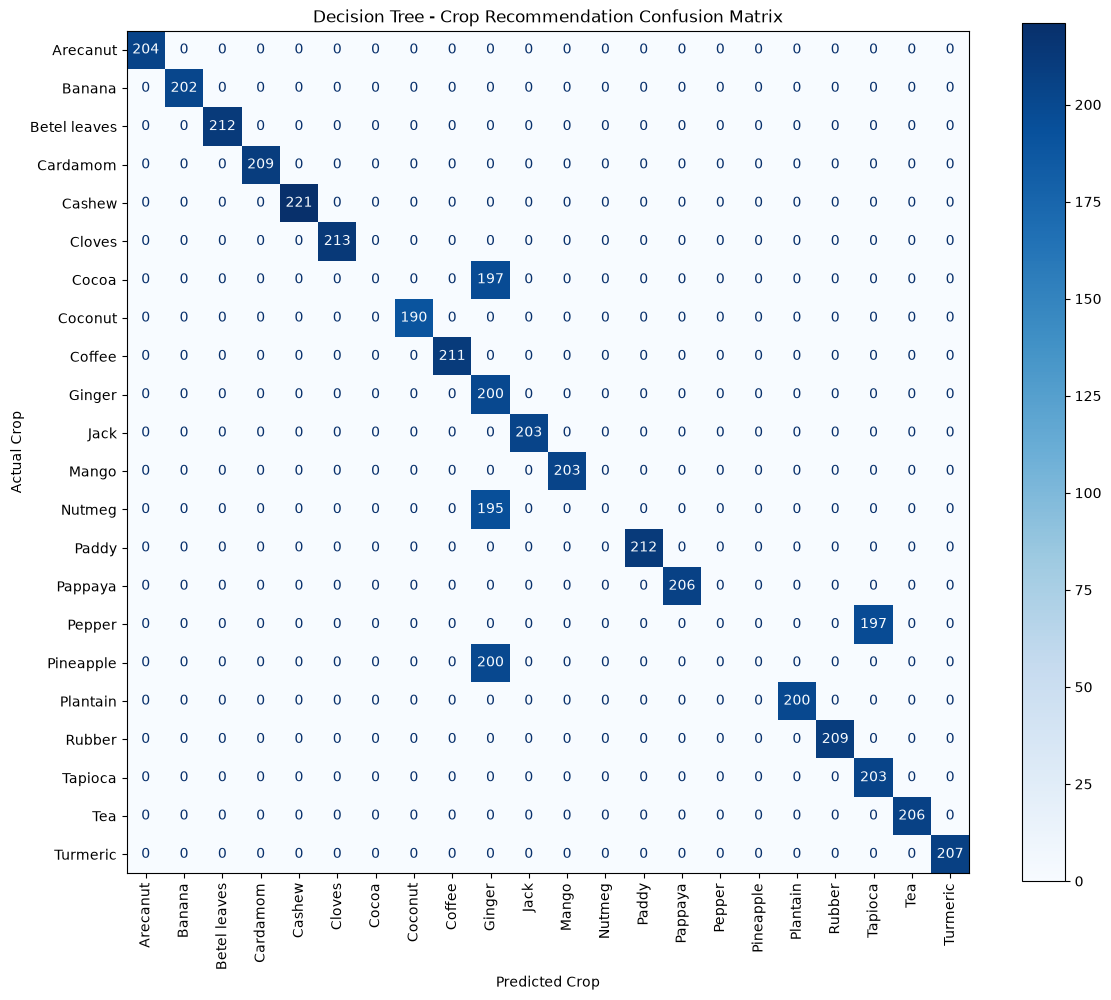



--------------------------------------------------
Random Forest
--------------------------------------------------
[[187   0   0   0   0   0   0   0  17   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0 202   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0 212   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0 206   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   3   0]
 [  0   0   0   0 220   0   0   0   0   0   0   1   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0 213   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0  12   0  61   0   0   0   0   0 103   0   0   0   0   0
    0   0  21   0]
 [  0   0   0   0   0   0   0 190   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  9   0   0   0   0   0   0   0 199   0   0   0   0   0   0   0   0   3
    0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 184   0

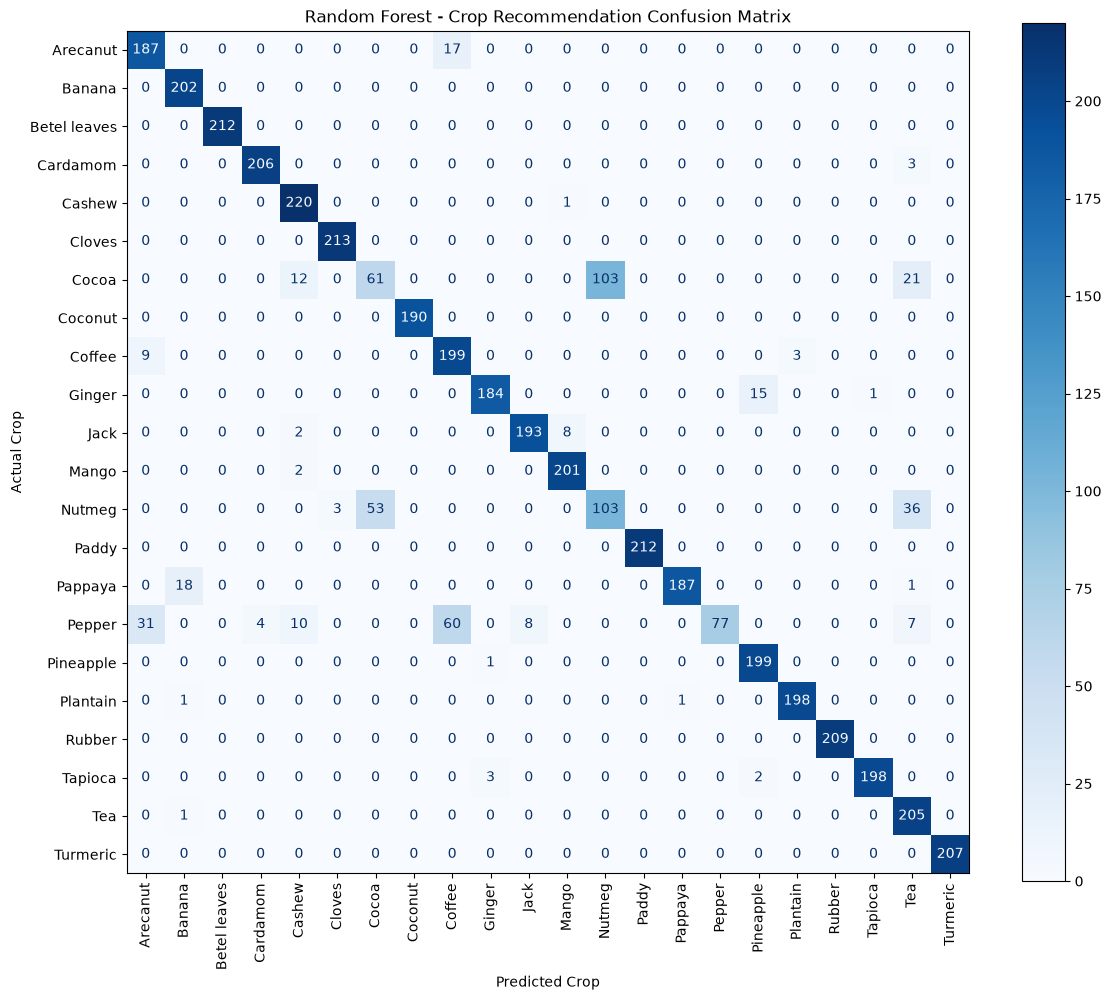



--------------------------------------------------
Naive Bayes
--------------------------------------------------
[[204   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0 202   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0 212   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0 209   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0 221   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0 213   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 197   0
    0   0   0   0]
 [  0   0   0   0   0   0   0 190   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0 211   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  

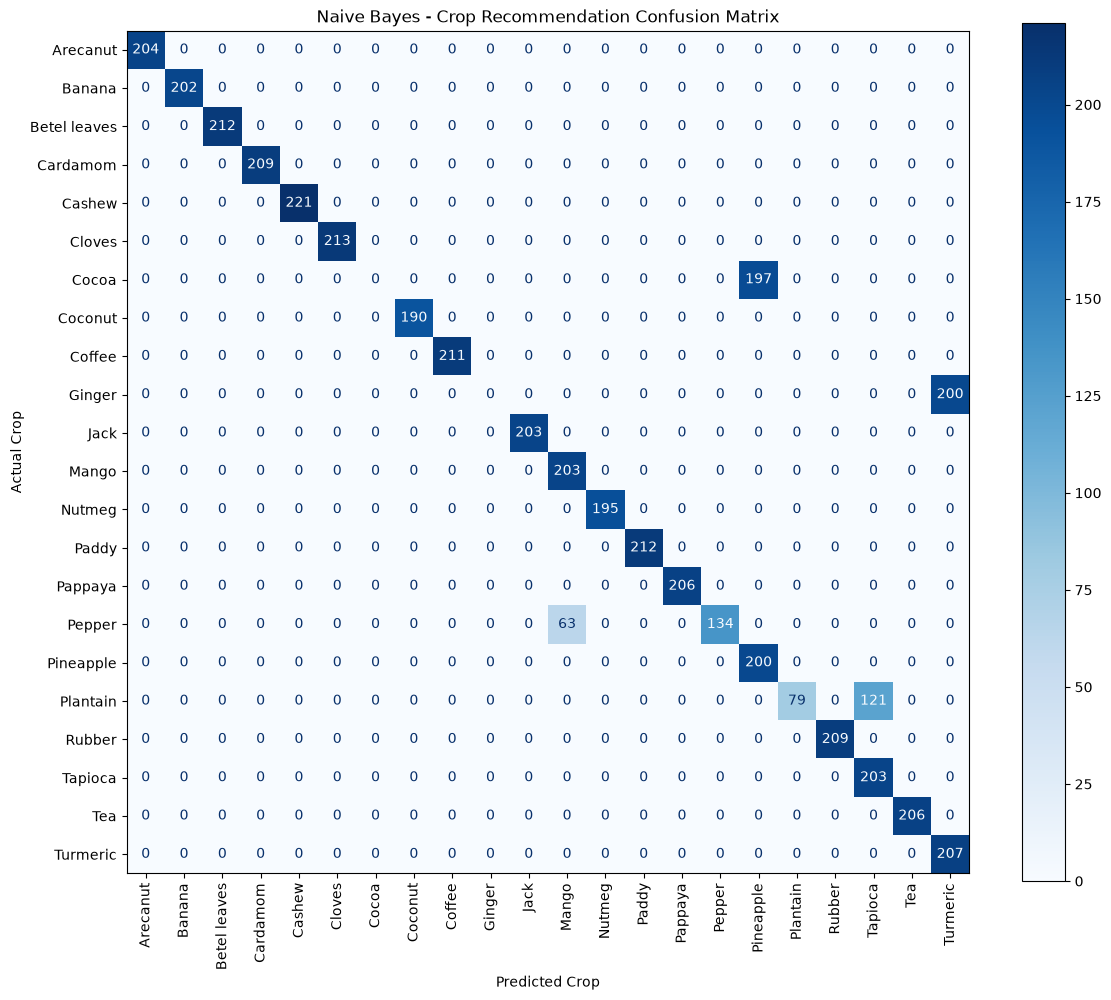



--------------------------------------------------
SVM
--------------------------------------------------
[[204   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0 202   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0 212   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0 209   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0 221   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0 213   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 197   0
    0   0   0   0]
 [  0   0   0   0   0   0   0 190   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0 211   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0 200   0   0   0   0   0   0   0  

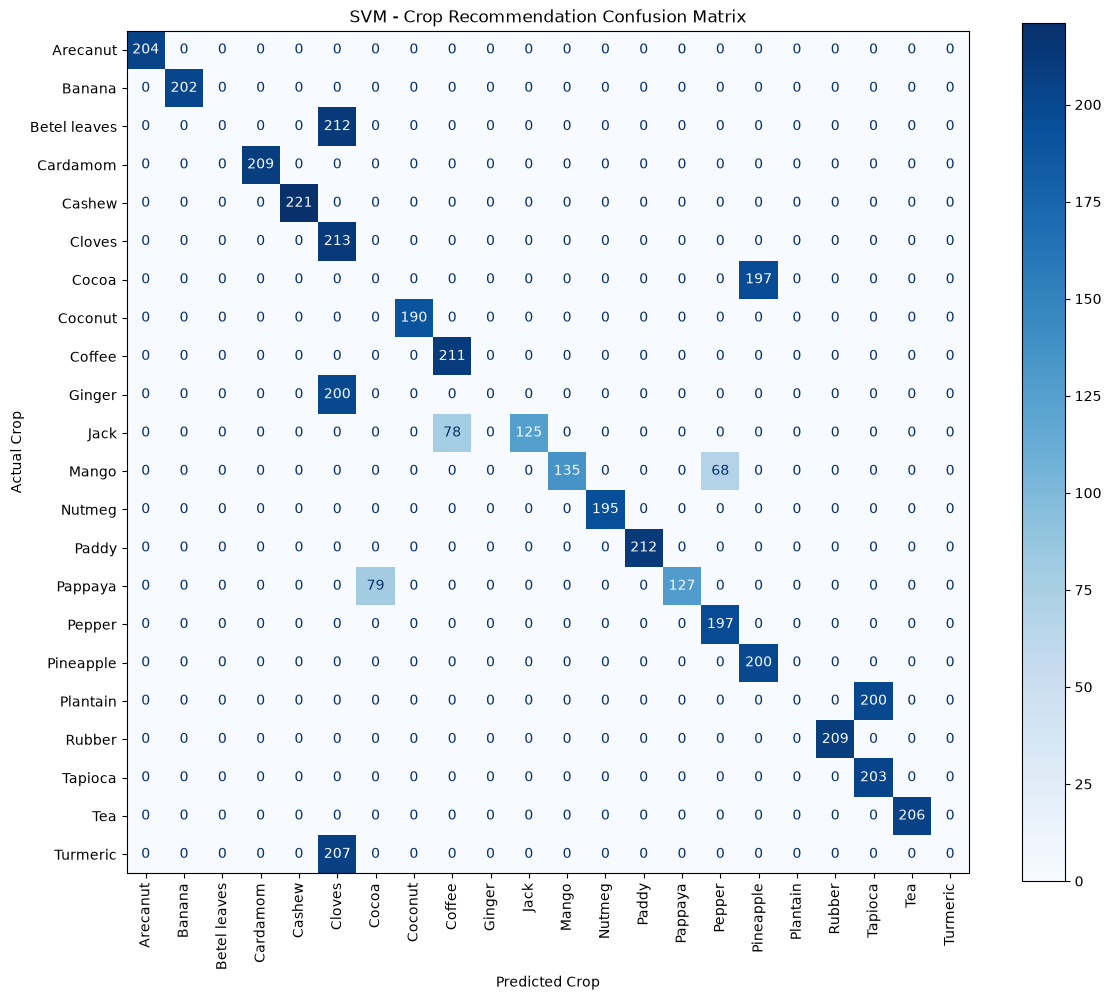

In [78]:
import pandas as pd
import warnings

from sklearn.naive_bayes import GaussianNB

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    "../data/kerala_crop_project_final_15000_recent.csv"
)


# ============================================================
# HANDLE MISSING VALUES
# ============================================================

for col in df.select_dtypes(include=["number"]).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=["object", "str"]).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])


# ============================================================
# FEATURES
# ============================================================

features = [
    "Area",
    "Area_Cent",
    "Soil_Type",
    "Soil_pH",
    "Nitrogen_N_kg_ha",
    "Phosphorus_P_kg_ha",
    "Potassium_K_kg_ha",
    "Rainfall_mm",
    "Temperature_C",
    "Humidity_percent",
    "Irrigation_Level",
    "Season"
]

X = df[features].copy()
y = df["Crop"].astype(str)


# ============================================================
# ENCODE CATEGORICAL FEATURES
# ============================================================

for col in [
    "Soil_Type",
    "Irrigation_Level",
    "Season"
]:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )


# ============================================================
# ENCODE TARGET
# ============================================================

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# ============================================================
# SCALE FEATURES
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# MODELS
# ============================================================

models = {

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=8,
            min_samples_split=100,
            min_samples_leaf=50,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=25,
            max_depth=3,
            min_samples_split=270,
            min_samples_leaf=100,
            max_features=0.2,
            random_state=42,
            n_jobs=-1
        ),

    "Naive Bayes":
        GaussianNB(
            var_smoothing=1e-3
        ),

    "SVM":
        SVC(
            C=5.0
        )
}


# ============================================================
# TRAIN AND SHOW ACCURACY
# ============================================================

print("=" * 50)
print("CROP RECOMMENDATION - ACCURACY")
print("=" * 50)

results = []


# Store predictions for confusion matrices
predictions = {}


for name, model in models.items():

    # Train
    model.fit(
        X_train,
        y_train
    )

    # Prediction
    prediction = model.predict(
        X_test
    )

    # Save prediction
    predictions[name] = prediction

    # Accuracy
    accuracy = accuracy_score(
        y_test,
        prediction
    )

    results.append(
        [name, accuracy]
    )

    print(
        f"{name:<25} : {accuracy:.2%}"
    )


# ============================================================
# RESULT
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Accuracy"
    ]
)


print("\n" + "=" * 50)
print("RESULT")
print("=" * 50)

print(
    results_df.to_string(index=False)
)


# ============================================================
# BEST ALGORITHM
# ============================================================

best = results_df.loc[
    results_df["Accuracy"].idxmax()
]


print("\n" + "=" * 50)
print("BEST ALGORITHM")
print("=" * 50)

print(
    "Algorithm :",
    best["Algorithm"]
)

print(
    "Accuracy  :",
    f"{best['Accuracy']:.2%}"
)


# ============================================================
# CONFUSION MATRICES
# ============================================================

print("\n" + "=" * 50)
print("CONFUSION MATRICES")
print("=" * 50)


for name, prediction in predictions.items():

    cm = confusion_matrix(
        y_test,
        prediction
    )

    print("\n")
    print("-" * 50)
    print(name)
    print("-" * 50)

    print(cm)

    # Create graph
    fig, ax = plt.subplots(
        figsize=(12, 10)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=target_encoder.classes_
    )

    disp.plot(
        ax=ax,
        xticks_rotation=90,
        values_format="d",
        cmap="Blues"
    )

    plt.title(
        f"{name} - Crop Recommendation Confusion Matrix"
    )

    plt.xlabel(
        "Predicted Crop"
    )

    plt.ylabel(
        "Actual Crop"
    )

    plt.tight_layout()

    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import warnings
import os
import joblib

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    "../data/kerala_crop_project_final_15000_recent.csv"
)

print("Dataset loaded:", df.shape)


# ============================================================
# TARGET
# ============================================================

df["Yield_kg_ha"] = pd.to_numeric(
    df["Yield_kg_ha"],
    errors="coerce"
)

df = df.dropna(
    subset=["Yield_kg_ha"]
)


# ============================================================
# FEATURES
# ============================================================

features = [
    "Crop",
    "Area",
    "Area_Cent",
    "Soil_Type",
    "Soil_pH",
    "Nitrogen_N_kg_ha",
    "Phosphorus_P_kg_ha",
    "Potassium_K_kg_ha",
    "Rainfall_mm",
    "Temperature_C",
    "Humidity_percent",
    "Irrigation_Level",
    "Season"
]

X = df[features].copy()

y = df["Yield_kg_ha"].copy()


# ============================================================
# FEATURE TYPES
# ============================================================

categorical_features = [
    "Crop",
    "Soil_Type",
    "Irrigation_Level",
    "Season"
]

numeric_features = [
    "Area",
    "Area_Cent",
    "Soil_pH",
    "Nitrogen_N_kg_ha",
    "Phosphorus_P_kg_ha",
    "Potassium_K_kg_ha",
    "Rainfall_mm",
    "Temperature_C",
    "Humidity_percent"
]


# ============================================================
# MISSING VALUES
# ============================================================

for col in numeric_features:

    X[col] = pd.to_numeric(
        X[col],
        errors="coerce"
    )

    X[col] = X[col].fillna(
        X[col].median()
    )


for col in categorical_features:

    X[col] = X[col].fillna(
        X[col].mode()[0]
    )


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


# ============================================================
# ENCODING
# ============================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore"
            ),

            categorical_features
        )

    ],

    remainder="passthrough"
)


# ============================================================
# MODELS
# ============================================================

models = {

    "Decision Tree":

        DecisionTreeClassifier(

            max_depth=8,

            min_samples_split=100,

            min_samples_leaf=50,

            random_state=42

        ),

    "Random Forest":

        RandomForestClassifier(
            n_estimators=30,
            max_depth=3,
            min_samples_split=220,
            min_samples_leaf=80,
            max_features=0.25,
            random_state=42,
            n_jobs=-1
        ),

    "Naive Bayes":

        GaussianNB(

            var_smoothing=1e-3

        ),


    "SVM":

        SVC(

            C=5.0,

            probability=True

        )

}



# ============================================================
# TRAIN + EVALUATION
# ============================================================

print("\n")

print("=" * 75)

print("             CROP YIELD PREDICTION")

print("=" * 75)


results = []

random_forest_pipeline = None


for name, model in models.items():

    pipeline = Pipeline(

        steps=[

            (
                "preprocessor",
                preprocessor
            ),

            (
                "model",
                model
            )

        ]
    )


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    pipeline.fit(
        X_train,
        y_train
    )


    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    prediction = pipeline.predict(
        X_test
    )


    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    r2 = r2_score(
        y_test,
        prediction
    )


    mae = mean_absolute_error(
        y_test,
        prediction
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )


    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    results.append(
        [
            name,
            r2,
            mae,
            rmse
        ]
    )


    # --------------------------------------------------------
    # SAVE RANDOM FOREST PIPELINE FOR LATER
    # --------------------------------------------------------

    if name == "Random Forest":

        random_forest_pipeline = pipeline


    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    print(
        f"{name:<25} "
        f"R²: {r2:.4f}   "
        f"MAE: {mae:.2f}   "
        f"RMSE: {rmse:.2f}"
    )


# ============================================================
# RESULT DATAFRAME
# ============================================================

results_df = pd.DataFrame(

    results,

    columns=[
        "Algorithm",
        "R2 Score",
        "MAE",
        "RMSE"
    ]
)


# ============================================================
# DISPLAY RESULT
# ============================================================

print("\n")

print("=" * 75)

print("                         RESULT")

print("=" * 75)


print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# BEST ALGORITHM BASED ON R²
# ============================================================

best = results_df.loc[
    results_df["R2 Score"].idxmax()
]


print("\n")

print("=" * 75)

print("                    BEST ALGORITHM")

print("=" * 75)


print(
    "Algorithm :",
    best["Algorithm"]
)


print(
    "R² Score  :",
    f"{best['R2 Score']:.4f}"
)


print(
    "MAE       :",
    f"{best['MAE']:.2f}"
)


print(
    "RMSE      :",
    f"{best['RMSE']:.2f}"
)


# ============================================================
# SAVE RANDOM FOREST MODEL
# ============================================================

print("\n")

print("=" * 75)

print("              SAVING RANDOM FOREST MODEL")

print("=" * 75)


# Create models folder

save_folder = "../models"

os.makedirs(
    save_folder,
    exist_ok=True
)


# Model path

model_path = os.path.join(
    save_folder,
    "random_forest_crop_yield.pkl"
)


# Save complete pipeline

joblib.dump(
    random_forest_pipeline,
    model_path
)


print(
    "Random Forest model saved successfully!"
)

print(
    "Saved at:",
    model_path
)


print("\n")

print("=" * 75)

print("                    MODEL SAVED")

print("=" * 75)

Dataset loaded: (15000, 21)


             CROP YIELD PREDICTION
Ridge Regression          R²: 0.8761   MAE: 2479.05   RMSE: 3870.08
Decision Tree             R²: 0.6157   MAE: 3675.37   RMSE: 6815.48
Random Forest             R²: 0.9283   MAE: 2322.69   RMSE: 2944.18
Gradient Boosting         R²: 0.7675   MAE: 4112.46   RMSE: 5301.00


                         RESULT
        Algorithm  R2 Score         MAE        RMSE
 Ridge Regression  0.876085 2479.046601 3870.081681
    Decision Tree  0.615696 3675.366677 6815.482475
    Random Forest  0.928285 2322.693617 2944.184796
Gradient Boosting  0.767514 4112.456448 5300.998498


                    BEST ALGORITHM
Algorithm : Random Forest
R² Score  : 0.9283
MAE       : 2322.69
RMSE      : 2944.18


              SAVING RANDOM FOREST MODEL
Random Forest model saved successfully!
Saved at: ../models\random_forest_crop_yield.pkl


                    MODEL SAVED


Dataset loaded: (15000, 21)


             CROP YIELD PREDICTION
Ridge Regression         R²: 0.8761   MAE: 2479.05   RMSE: 3870.08
Decision Tree            R²: 0.3869   MAE: 4554.44   RMSE: 8608.56
Random Forest            R²: 0.9284   MAE: 2324.12   RMSE: 2941.41
Gradient Boosting        R²: 0.7675   MAE: 4112.46   RMSE: 5301.00


                         RESULT
        Algorithm  R2 Score         MAE        RMSE
 Ridge Regression  0.876085 2479.046601 3870.081681
    Decision Tree  0.386883 4554.442566 8608.561341
    Random Forest  0.928420 2324.116811 2941.409998
Gradient Boosting  0.767514 4112.456448 5300.998498


                    BEST ALGORITHM
Algorithm : Random Forest
R² Score  : 0.9284
MAE       : 2324.12
RMSE      : 2941.41


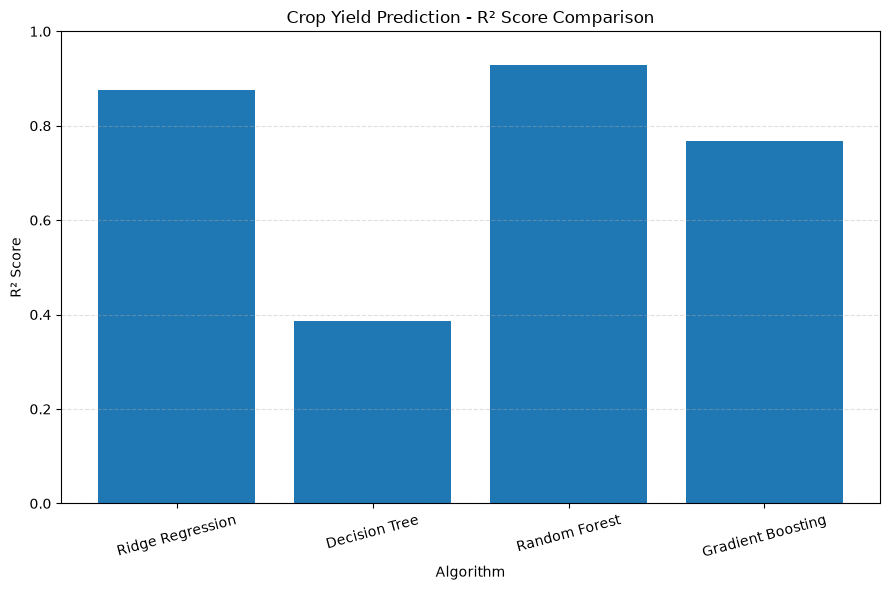

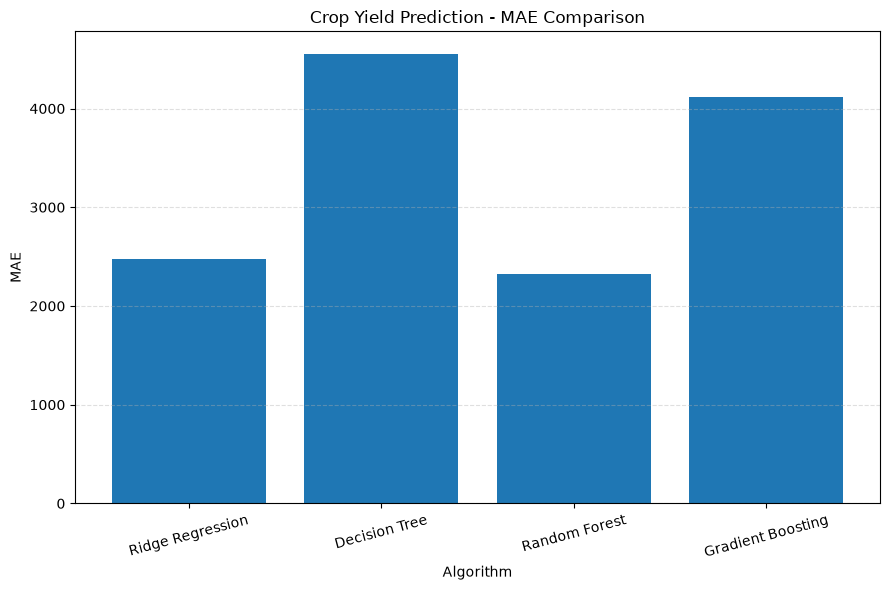

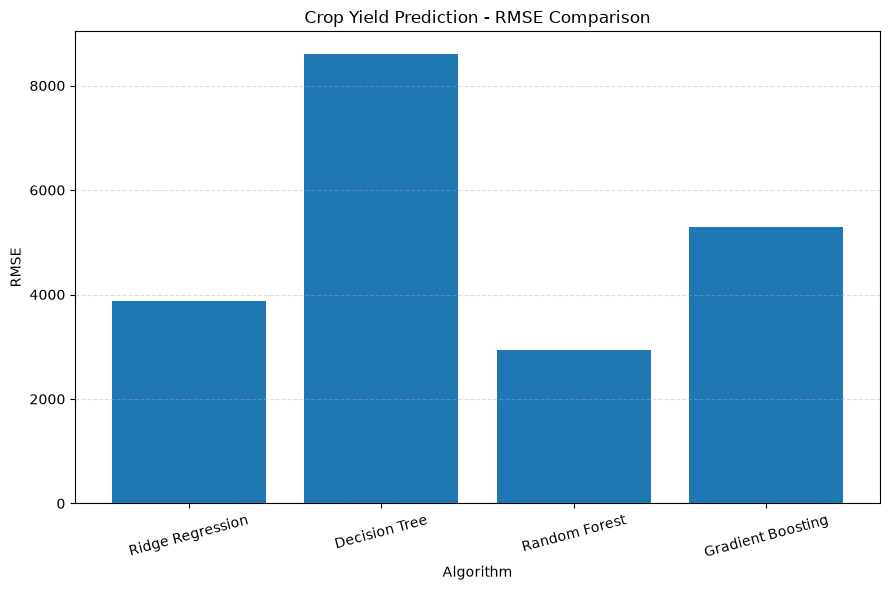

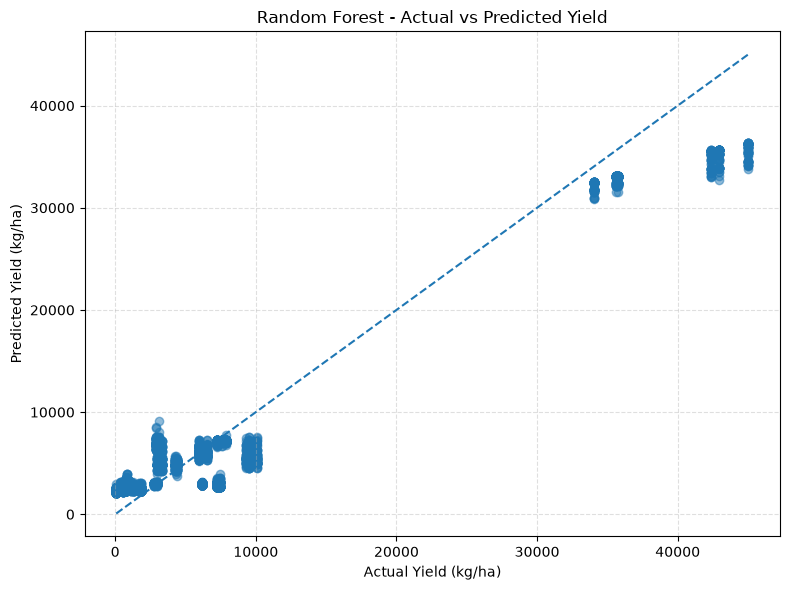

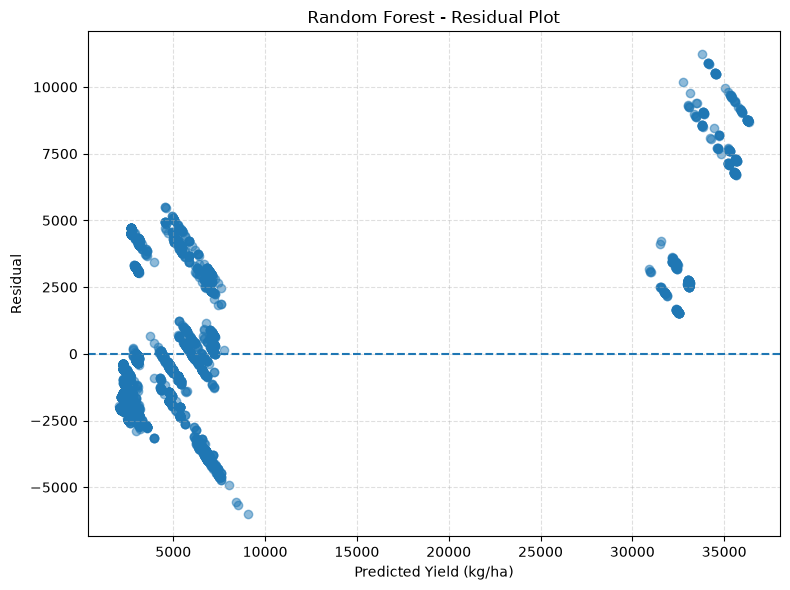

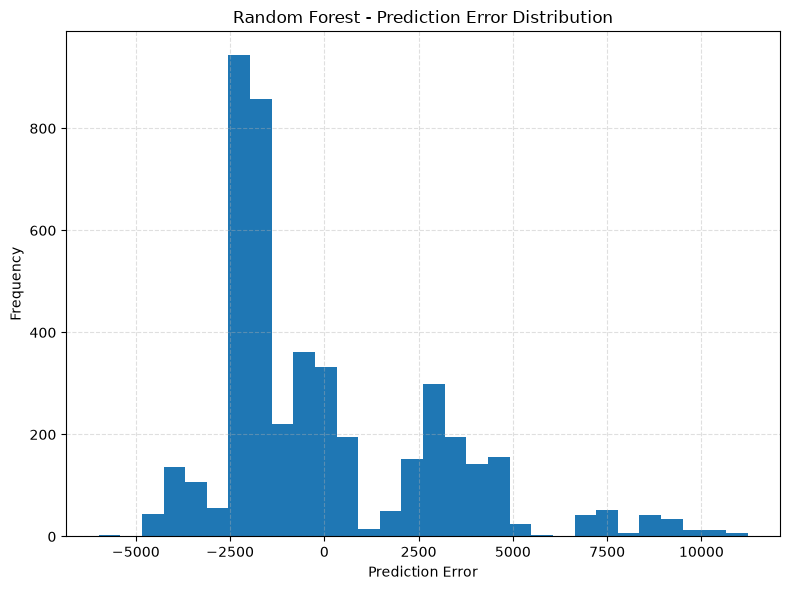



                  ALL GRAPHS GENERATED


In [3]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    "../data/kerala_crop_project_final_15000_recent.csv"
)

print("Dataset loaded:", df.shape)


# ============================================================
# TARGET
# ============================================================

df["Yield_kg_ha"] = pd.to_numeric(
    df["Yield_kg_ha"],
    errors="coerce"
)

df = df.dropna(
    subset=["Yield_kg_ha"]
)


# ============================================================
# FEATURES
# ============================================================

features = [
    "Crop",
    "Area",
    "Area_Cent",
    "Soil_Type",
    "Soil_pH",
    "Nitrogen_N_kg_ha",
    "Phosphorus_P_kg_ha",
    "Potassium_K_kg_ha",
    "Rainfall_mm",
    "Temperature_C",
    "Humidity_percent",
    "Irrigation_Level",
    "Season"
]

X = df[features].copy()
y = df["Yield_kg_ha"].copy()


# ============================================================
# FEATURE TYPES
# ============================================================

categorical_features = [
    "Crop",
    "Soil_Type",
    "Irrigation_Level",
    "Season"
]

numeric_features = [
    "Area",
    "Area_Cent",
    "Soil_pH",
    "Nitrogen_N_kg_ha",
    "Phosphorus_P_kg_ha",
    "Potassium_K_kg_ha",
    "Rainfall_mm",
    "Temperature_C",
    "Humidity_percent"
]


# ============================================================
# MISSING VALUES
# ============================================================

for col in numeric_features:
    X[col] = X[col].fillna(
        X[col].median()
    )

for col in categorical_features:
    X[col] = X[col].fillna(
        X[col].mode()[0]
    )


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


# ============================================================
# ENCODING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)


# ============================================================
# MODELS
# ============================================================

models = {

    "Ridge Regression":
        Ridge(
            alpha=300
        ),

    "Decision Tree":
        DecisionTreeRegressor(
            max_depth=2,
            min_samples_split=300,
            min_samples_leaf=150,
            max_features=0.4,
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=25,
            max_depth=3,
            min_samples_split=180,
            min_samples_leaf=75,
            max_features=0.3,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=60,
            max_depth=1,
            learning_rate=0.03,
            min_samples_split=180,
            min_samples_leaf=90,
            random_state=42
        )
}


# ============================================================
# TRAIN + EVALUATION
# ============================================================

print("\n")
print("=" * 75)
print("             CROP YIELD PREDICTION")
print("=" * 75)

results = []

trained_pipelines = {}

predictions = {}


for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # TRAIN
    pipeline.fit(
        X_train,
        y_train
    )

    # PREDICTION
    prediction = pipeline.predict(
        X_test
    )

    # METRICS
    r2 = r2_score(
        y_test,
        prediction
    )

    mae = mean_absolute_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )

    results.append([
        name,
        r2,
        mae,
        rmse
    ])

    trained_pipelines[name] = pipeline
    predictions[name] = prediction

    print(
        f"{name:<25}"
        f"R²: {r2:.4f}   "
        f"MAE: {mae:.2f}   "
        f"RMSE: {rmse:.2f}"
    )


# ============================================================
# RESULT DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "R2 Score",
        "MAE",
        "RMSE"
    ]
)


print("\n")
print("=" * 75)
print("                         RESULT")
print("=" * 75)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# BEST ALGORITHM
# ============================================================

best = results_df.loc[
    results_df["R2 Score"].idxmax()
]

print("\n")
print("=" * 75)
print("                    BEST ALGORITHM")
print("=" * 75)

print(
    "Algorithm :",
    best["Algorithm"]
)

print(
    "R² Score  :",
    f"{best['R2 Score']:.4f}"
)

print(
    "MAE       :",
    f"{best['MAE']:.2f}"
)

print(
    "RMSE      :",
    f"{best['RMSE']:.2f}"
)


# ============================================================
# GRAPH 1 - R² SCORE COMPARISON
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    results_df["Algorithm"],
    results_df["R2 Score"]
)

plt.xlabel("Algorithm")
plt.ylabel("R² Score")
plt.title("Crop Yield Prediction - R² Score Comparison")

plt.ylim(0, 1)

plt.xticks(
    rotation=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 2 - MAE COMPARISON
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    results_df["Algorithm"],
    results_df["MAE"]
)

plt.xlabel("Algorithm")
plt.ylabel("MAE")
plt.title("Crop Yield Prediction - MAE Comparison")

plt.xticks(
    rotation=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 3 - RMSE COMPARISON
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    results_df["Algorithm"],
    results_df["RMSE"]
)

plt.xlabel("Algorithm")
plt.ylabel("RMSE")
plt.title("Crop Yield Prediction - RMSE Comparison")

plt.xticks(
    rotation=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 4 - ACTUAL VS PREDICTED
# BEST MODEL
# ============================================================

best_model_name = best["Algorithm"]

best_prediction = predictions[
    best_model_name
]

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_prediction,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Yield (kg/ha)")
plt.ylabel("Predicted Yield (kg/ha)")

plt.title(
    f"{best_model_name} - Actual vs Predicted Yield"
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 5 - RESIDUAL PLOT
# BEST MODEL
# ============================================================

residuals = (
    y_test.values -
    best_prediction
)

plt.figure(figsize=(8, 6))

plt.scatter(
    best_prediction,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Yield (kg/ha)")
plt.ylabel("Residual")

plt.title(
    f"{best_model_name} - Residual Plot"
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 6 - ERROR DISTRIBUTION
# BEST MODEL
# ============================================================

plt.figure(figsize=(8, 6))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.title(
    f"{best_model_name} - Prediction Error Distribution"
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


print("\n")
print("=" * 75)
print("                  ALL GRAPHS GENERATED")
print("=" * 75)

In [83]:
print("Soil Types:")
print(df["Soil_Type"].unique())

print("\nIrrigation Levels:")
print(df["Irrigation_Level"].unique())

print("\nSeasons:")
print(df["Season"].unique())

print("\nCrops:")
print(df["Crop"].unique())

Soil Types:
<StringArray>
['Loamy', 'Clay', 'Sandy', 'Silty']
Length: 4, dtype: str

Irrigation Levels:
<StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

Seasons:
<StringArray>
['Kharif', 'Perennial']
Length: 2, dtype: str

Crops:
<StringArray>
[     'Tapioca',        'Paddy',     'Turmeric',       'Coffee',
       'Rubber',     'Plantain', 'Betel leaves',        'Cocoa',
     'Cardamom',      'Pappaya',      'Coconut',        'Mango',
         'Jack',       'Banana',       'Ginger',       'Cloves',
       'Nutmeg',     'Arecanut',       'Pepper',       'Cashew',
    'Pineapple',          'Tea']
Length: 22, dtype: str


       CROP RECOMMENDATION - ACCURACY
Decision Tree             : 75.93%
Random Forest             : 83.62%
KNN                       : 79.18%
SVM                       : 83.56%

                    RESULTS
    Algorithm  Accuracy
Decision Tree  0.759333
Random Forest  0.836222
          KNN  0.791778
          SVM  0.835556

                  BEST ALGORITHM
Algorithm : Random Forest
Accuracy  : 83.62%

              CONFUSION MATRICES


------------------------------------------------------------
Decision Tree
------------------------------------------------------------
[[158   0   0   1   0   2  11   0   4   0   0   0  20   0   0   8   0   0
    0   0   0   0]
 [  0  93   1   0   0   0   0   0   0   0   0   0   0   0   4   0   0 104
    0   0   0   0]
 [  0   1 181   0   0   0   0   0   0   0   0   0   0   0  29   0   0   1
    0   0   0   0]
 [  1   0   0 165   0  12   1   0   1   0   0   0   7   0   0  17   0   0
    0   0   5   0]
 [  0   0   0   0 188   0   0   0   0   0   1  32 

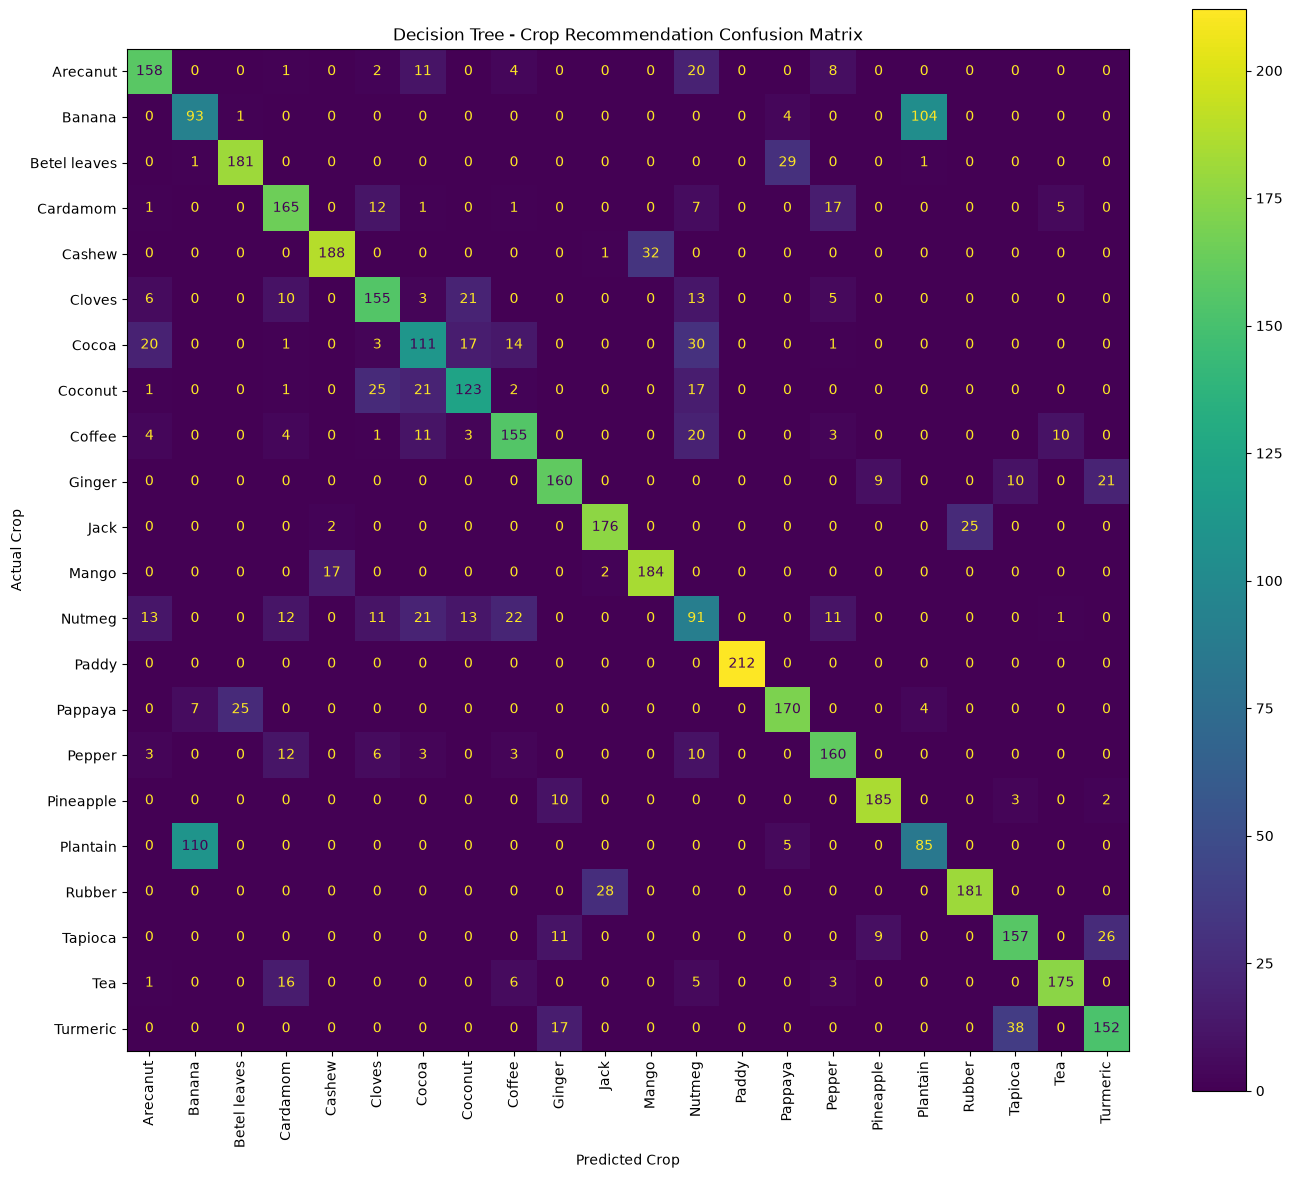



------------------------------------------------------------
Random Forest
------------------------------------------------------------
[[169   0   0   1   0   2   9   0   2   0   0   0  13   0   0   8   0   0
    0   0   0   0]
 [  0 106   0   0   0   0   0   0   0   0   0   0   0   0   4   0   0  92
    0   0   0   0]
 [  0   0 193   0   0   0   0   0   0   0   0   0   0   0  19   0   0   0
    0   0   0   0]
 [  0   0   0 180   0  10   0   0   1   0   0   0   8   0   0   7   0   0
    0   0   3   0]
 [  0   0   0   0 204   0   0   0   0   0   0  17   0   0   0   0   0   0
    0   0   0   0]
 [  2   0   0   4   0 189   1  12   0   0   0   0   5   0   0   0   0   0
    0   0   0   0]
 [ 12   0   0   0   0   2 143  11   7   0   0   0  20   0   0   2   0   0
    0   0   0   0]
 [  0   0   0   1   0  21  14 143   0   0   0   0  11   0   0   0   0   0
    0   0   0   0]
 [  5   0   0   3   0   1   7   3 175   0   0   0  11   0   0   2   0   0
    0   0   4   0]
 [  0   0   0   0   0   0

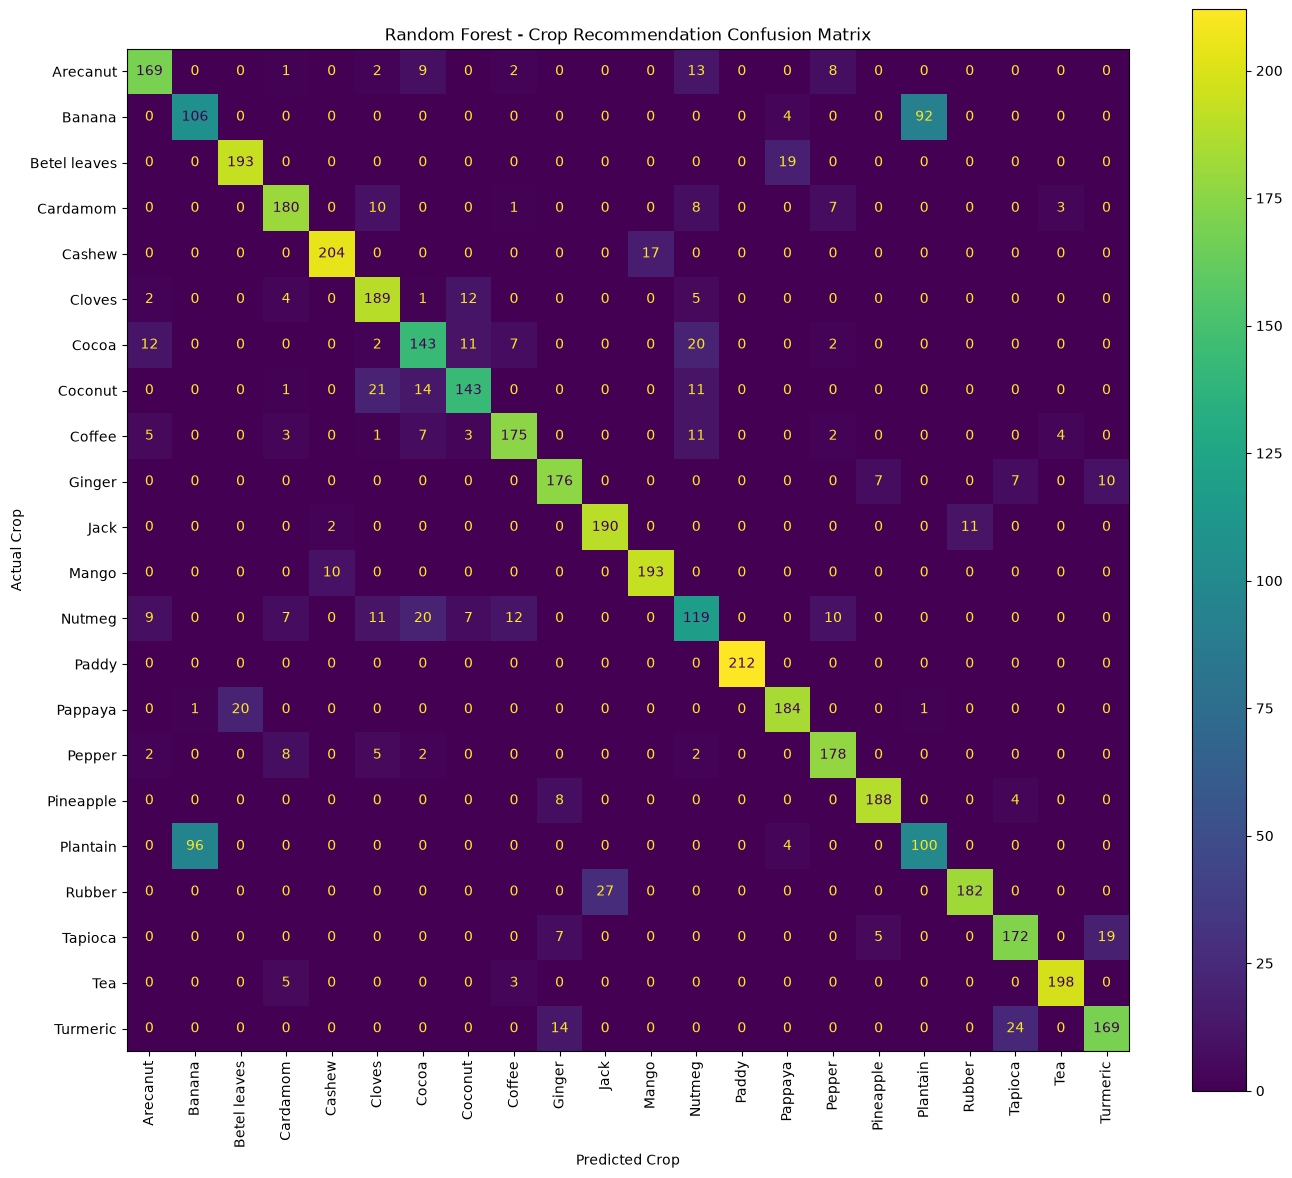



------------------------------------------------------------
KNN
------------------------------------------------------------
[[163   0   0   0   0   2  12   0   5   0   0   0  18   0   0   4   0   0
    0   0   0   0]
 [  0 118   0   0   0   0   0   0   0   0   0   0   0   0   3   0   0  81
    0   0   0   0]
 [  0   1 188   0   0   0   0   0   0   0   0   0   0   0  23   0   0   0
    0   0   0   0]
 [  0   0   0 177   0   9   1   0   2   0   0   0   5   0   0  13   0   0
    0   0   2   0]
 [  0   0   0   0 194   0   0   0   0   0   0  27   0   0   0   0   0   0
    0   0   0   0]
 [  3   0   0  14   0 164   2  21   0   0   0   0   9   0   0   0   0   0
    0   0   0   0]
 [ 13   0   0   0   0   3 148  10   8   0   0   0  14   0   0   1   0   0
    0   0   0   0]
 [  1   0   0   0   0  29  28 121   0   0   0   0  11   0   0   0   0   0
    0   0   0   0]
 [  7   0   0   6   0   1  10   3 164   0   0   0  16   0   0   2   0   0
    0   0   2   0]
 [  0   0   0   0   0   0   0   0  

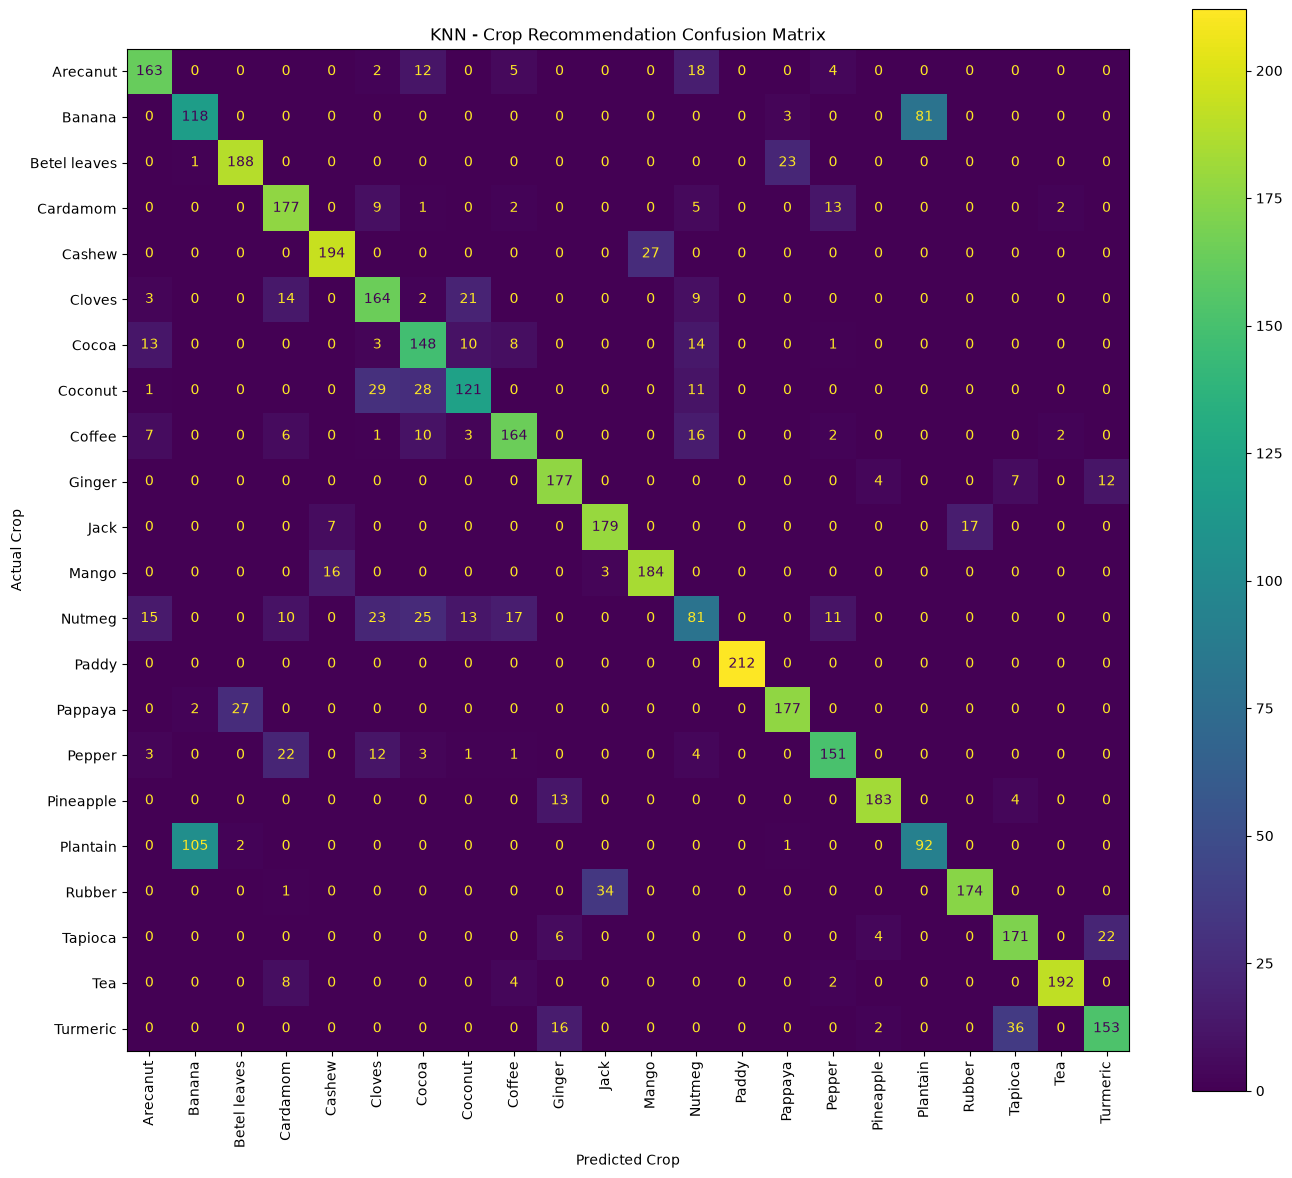



------------------------------------------------------------
SVM
------------------------------------------------------------
[[165   0   0   0   0   3  15   0   2   0   0   0  13   0   0   6   0   0
    0   0   0   0]
 [  0 139   0   0   0   0   0   0   0   0   0   0   0   0   4   0   0  59
    0   0   0   0]
 [  0   0 197   0   0   0   0   0   0   0   0   0   0   0  15   0   0   0
    0   0   0   0]
 [  0   0   0 181   0   7   0   0   1   0   0   0   6   0   0  12   0   0
    0   0   2   0]
 [  0   0   0   0 201   0   0   0   0   0   0  20   0   0   0   0   0   0
    0   0   0   0]
 [  1   0   0   4   0 190   3  10   0   0   0   0   5   0   0   0   0   0
    0   0   0   0]
 [ 11   0   0   0   0   0 151   8   9   0   0   0  16   0   0   2   0   0
    0   0   0   0]
 [  1   0   0   0   0  18  16 146   0   0   0   0   8   0   0   1   0   0
    0   0   0   0]
 [  5   0   0   4   0   0  10   2 173   0   0   0  12   0   0   2   0   0
    0   0   3   0]
 [  0   0   0   0   0   0   0   0  

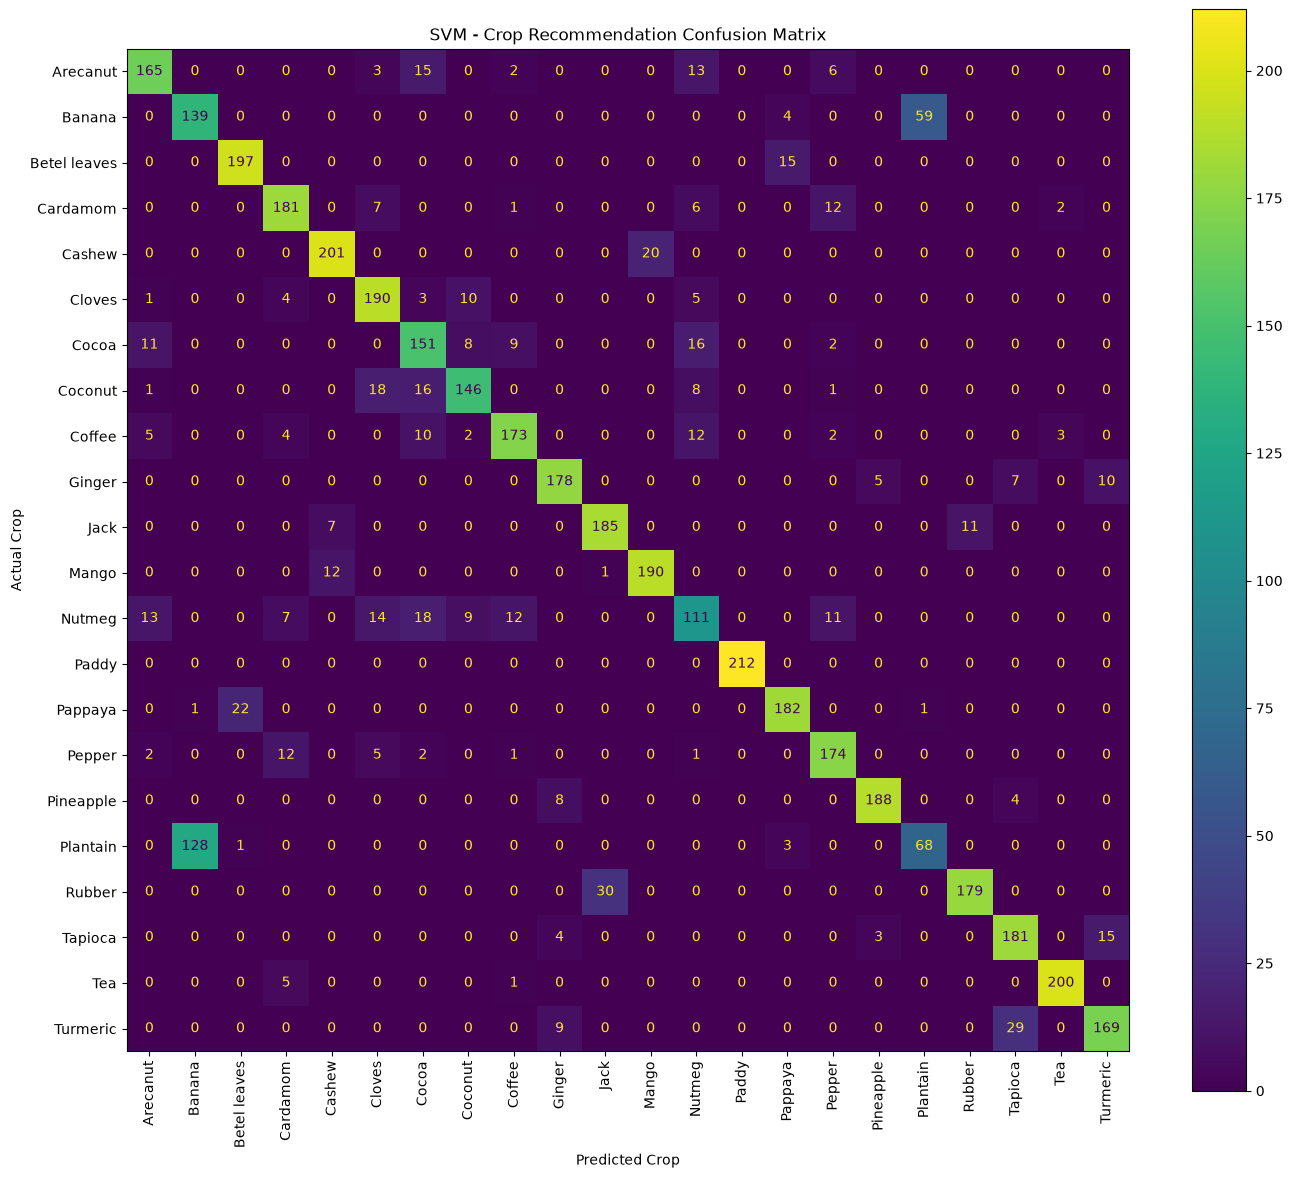

In [92]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    "../data/kerala_crop_project_final_15000_recent.csv"
)


# ============================================================
# HANDLE MISSING VALUES
# ============================================================

for col in df.select_dtypes(include=["number"]).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=["object", "str"]).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])


# ============================================================
# FEATURES
# ============================================================

features = [
    "Soil_Type",
    "Soil_pH",
    "Nitrogen_N_kg_ha",
    "Phosphorus_P_kg_ha",
    "Potassium_K_kg_ha",
    "Rainfall_mm",
    "Temperature_C",
    "Humidity_percent",
    "Irrigation_Level",
    "Season"
]

X = df[features].copy()
y = df["Crop"].astype(str)


# ============================================================
# ENCODE CATEGORICAL FEATURES
# ============================================================

for col in [
    "Soil_Type",
    "Irrigation_Level",
    "Season"
]:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )


# ============================================================
# ENCODE TARGET
# ============================================================

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# ============================================================
# SCALE FEATURES
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# MODELS
# ============================================================

models = {

    "Decision Tree":
        (
            DecisionTreeClassifier(
                random_state=42
            ),
            X_train,
            X_test
        ),

    "Random Forest":
        (
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            ),
            X_train,
            X_test
        ),

    "KNN":
        (
            KNeighborsClassifier(
                n_neighbors=5
            ),
            X_train_scaled,
            X_test_scaled
        ),

    "SVM":
        (
            SVC(
                C=0.5,
                kernel="rbf",
                gamma=0.01
            ),
            X_train_scaled,
            X_test_scaled
        )
}


# ============================================================
# TRAIN + ACCURACY + CONFUSION MATRIX
# ============================================================

print("=" * 60)
print("       CROP RECOMMENDATION - ACCURACY")
print("=" * 60)

results = []

predictions = {}


for name, (model, train_data, test_data) in models.items():

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.fit(
        train_data,
        y_train
    )


    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    prediction = model.predict(
        test_data
    )


    predictions[name] = prediction


    # --------------------------------------------------------
    # ACCURACY
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        prediction
    )


    results.append(
        [name, accuracy]
    )


    print(
        f"{name:<25} : {accuracy:.2%}"
    )


# ============================================================
# RESULT TABLE
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Accuracy"
    ]
)


print("\n" + "=" * 60)
print("                    RESULTS")
print("=" * 60)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# BEST ALGORITHM
# ============================================================

best = results_df.loc[
    results_df["Accuracy"].idxmax()
]


print("\n" + "=" * 60)
print("                  BEST ALGORITHM")
print("=" * 60)

print(
    "Algorithm :",
    best["Algorithm"]
)

print(
    "Accuracy  :",
    f"{best['Accuracy']:.2%}"
)


# ============================================================
# CONFUSION MATRICES
# ============================================================

print("\n" + "=" * 60)
print("              CONFUSION MATRICES")
print("=" * 60)


for name, prediction in predictions.items():

    cm = confusion_matrix(
        y_test,
        prediction
    )


    print("\n")
    print("-" * 60)
    print(name)
    print("-" * 60)

    print(cm)


    # --------------------------------------------------------
    # GRAPH
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(14, 12)
    )


    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=target_encoder.classes_
    )


    disp.plot(
        ax=ax,
        xticks_rotation=90,
        values_format="d"
    )


    plt.title(
        f"{name} - Crop Recommendation Confusion Matrix"
    )

    plt.xlabel(
        "Predicted Crop"
    )

    plt.ylabel(
        "Actual Crop"
    )

    plt.tight_layout()

    plt.show()